# IMDb Movie Reviews Sentiment Analysis

## Exploratory Data Analysis (EDA)

**Author:** Naitik Tiwari

**Dataset:** IMDb 50K Movie Reviews

**Goal:** Analyze movie reviews before building machine learning models.

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
plt.style.use("ggplot")

# Display all columns if needed
pd.set_option("display.max_columns", None)

In [65]:
print("Hello, Notebook!")

Hello, Notebook!


In [66]:
df = pd.read_csv("../data/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [67]:
df.shape

(50000, 2)

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [69]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(418)

In [71]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

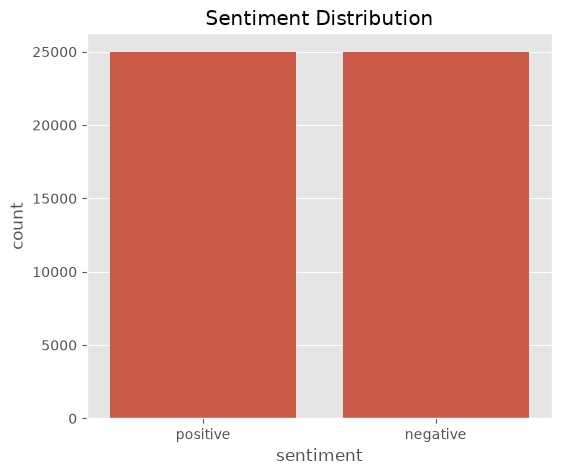

In [72]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")

plt.show()

In [73]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


## Review Length Analysis

To better understand the dataset, a new feature called `review_length` is created. This feature stores the number of characters in each review and helps analyze the distribution of review lengths as well as compare review lengths between positive and negative sentiments.

In [74]:
df["review_length"] = df["review"].str.len()

df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [75]:
df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

### Observation

- The dataset contains 50,000 reviews.
- The average review length is around 1,309 characters.
- Review lengths vary considerably, ranging from very short reviews to reviews exceeding 13,000 characters.
- This wide variation indicates that the dataset contains both concise opinions and detailed reviews.

In [76]:
df.groupby("sentiment")["review_length"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
sentiment,,,,
negative,1294.06436,973.0,32,8969
positive,1324.79768,968.0,65,13704


### Observation

- Positive reviews are slightly longer on average than negative reviews.
- However, the difference is relatively small.
- Review length alone is unlikely to be a strong predictor of sentiment, but it provides useful insight into the dataset.

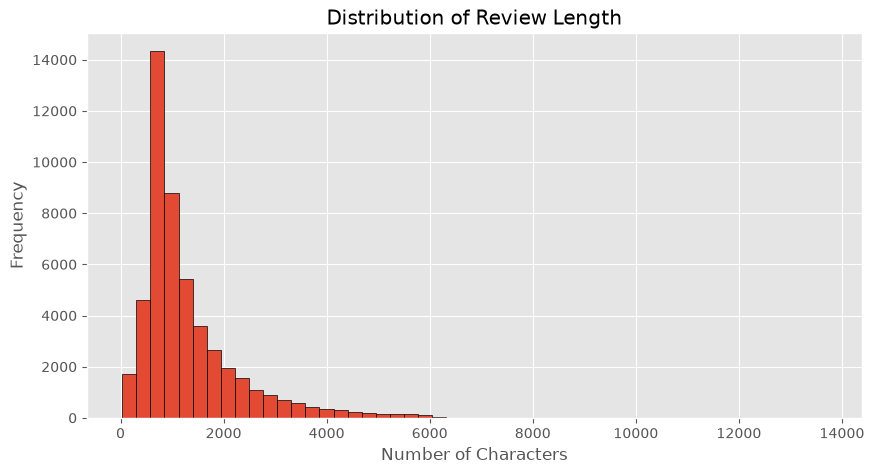

In [77]:
plt.figure(figsize=(10,5))

plt.hist(
    df["review_length"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Review Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

### Observation

- Most reviews contain between **500 and 2,000 characters**.
- The distribution is **right-skewed**, meaning the majority of reviews are relatively short while a small number of reviews are extremely long.
- A few reviews exceed **10,000 characters**, indicating the presence of outliers.
- The average review length is approximately **1,309 characters**, showing that IMDb reviews are generally detailed rather than one-line comments.

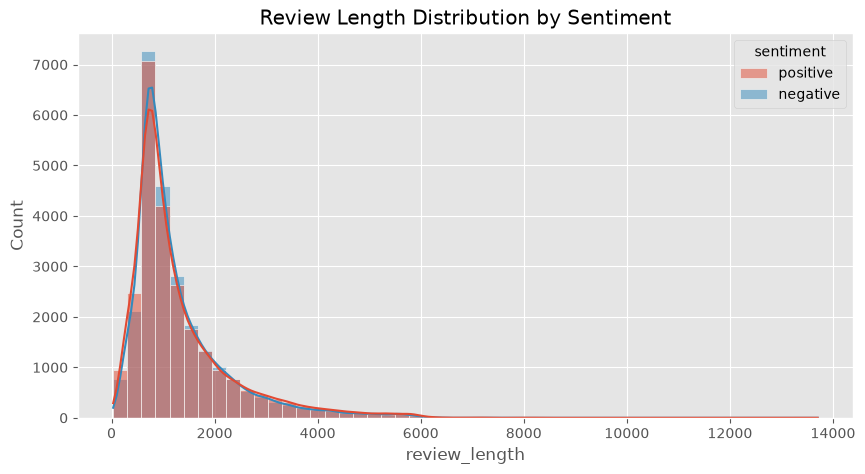

In [78]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="review_length",
    hue="sentiment",
    bins=50,
    kde=True
)

plt.title("Review Length Distribution by Sentiment")

plt.show()

### Observation

- Positive and negative reviews exhibit **very similar distributions** of review length.
- Both classes are concentrated between **500 and 2,000 characters**, with only a few exceptionally long reviews.
- Although positive reviews have a slightly higher average length than negative reviews, the difference is minimal.
- The significant overlap between the two distributions suggests that **review length alone is not a strong indicator of sentiment**.

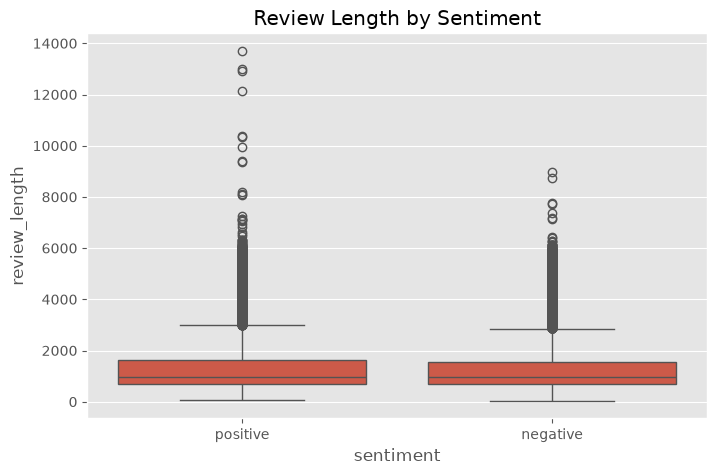

In [79]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")

plt.show()

## Conclusion

The review length analysis indicates that IMDb reviews vary considerably in size, with most reviews falling between **500 and 2,000 characters**. The distributions of positive and negative reviews are highly similar, showing substantial overlap. While positive reviews are slightly longer on average, the difference is not large enough to serve as a reliable predictor of sentiment. Therefore, review length provides useful descriptive insight into the dataset but is unlikely to contribute significantly as a standalone feature for sentiment classification.

## Identifying the Longest and Shortest Reviews

To better understand the range of review lengths in the dataset, we identify the five longest and five shortest reviews. This helps verify the variability in review sizes and highlights the presence of unusually short or exceptionally long reviews.

In [80]:
df.nlargest(
    5,
    "review_length"
)[["sentiment", "review_length"]]


,sentiment,review_length
31481,positive,13704
40521,positive,12988
31240,positive,12930
31436,positive,12129
5708,positive,10363


In [81]:
df.nsmallest(
    5,
    "review_length"
)[["sentiment", "review_length"]]

,sentiment,review_length
27521,negative,32
31072,negative,41
40817,negative,49
28920,negative,51
19874,negative,52


### Observation

- The longest reviews contain several thousand characters, indicating that some users provide highly detailed opinions and analyses.
- The shortest reviews consist of only a few words or sentences, representing brief reactions.
- Both positive and negative sentiments are present among the longest and shortest reviews.
- This wide variation confirms that review length differs greatly across the dataset and reinforces the presence of outliers observed in the previous visualizations.

## Saving the Feature-Engineered Dataset

After creating the `review_length` feature, the updated dataset is saved as a new CSV file named `imdb_with_length.csv`. This intermediate dataset captures the results of the feature engineering stage and serves as a checkpoint before moving on to text preprocessing.

Maintaining intermediate datasets makes the project workflow easier to understand, improves reproducibility, and clearly documents the transformation performed at each stage of the analysis.

In [82]:
df.to_csv(
    "../data/imdb_with_length.csv",
    index=False
)

### Observation

- The dataset has been successfully saved as **`imdb_with_length.csv`**.
- This version contains the newly created `review_length` feature while preserving the original review text and sentiment labels.
- Saving this intermediate dataset documents the completion of the feature engineering stage and provides a reusable checkpoint for subsequent preprocessing and machine learning tasks.

In [83]:
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re

## Word Cloud for Positive Reviews

A word cloud displays the most frequently occurring words in positive movie reviews. Larger words indicate higher frequency.

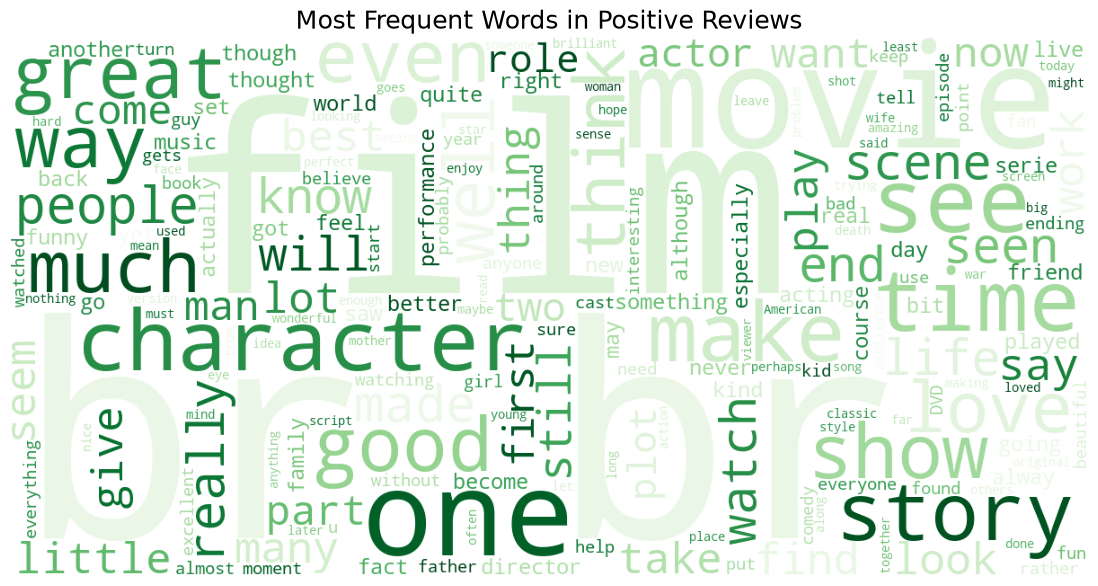

In [84]:
positive_reviews = " ".join(
    df[df["sentiment"] == "positive"]["review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Greens"
).generate(positive_reviews)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Positive Reviews", fontsize=18)

plt.show()

### Observation

The positive review word cloud is dominated by words such as *movie*, *film*, *one*, *good*, and *great*. This indicates that reviewers frequently use positive descriptive words while discussing the overall quality of the movie.

## Word Cloud for Negative Reviews

This visualization highlights the words that appear most frequently in negative movie reviews.

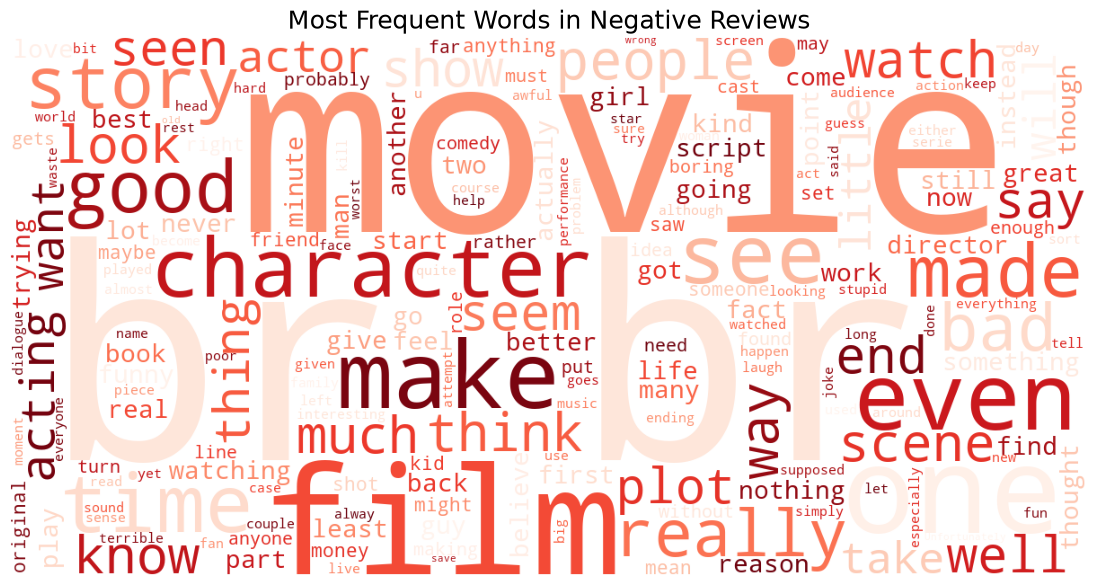

In [85]:
negative_reviews = " ".join(
    df[df["sentiment"] == "negative"]["review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds"
).generate(negative_reviews)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Negative Reviews", fontsize=18)

plt.show()

### Observation

Negative reviews commonly contain words such as *movie*, *film*, *bad*, *worst*, and *boring*. These words reflect dissatisfaction with different aspects of the movies.

In [86]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    return text

In [87]:
all_reviews = " ".join(df["review"])

all_reviews = clean_text(all_reviews)

In [88]:
words = all_reviews.split()

word_counts = Counter(words)

top_words = word_counts.most_common(20)

top_words

[('the', 667802),
 ('and', 324344),
 ('a', 322977),
 ('of', 289344),
 ('to', 268041),
 ('is', 211012),
 ('it', 190808),
 ('in', 186720),
 ('i', 175552),
 ('this', 150950),
 ('that', 143830),
 ('s', 129745),
 ('was', 95580),
 ('as', 91734),
 ('movie', 87945),
 ('for', 87451),
 ('with', 87349),
 ('but', 83530),
 ('film', 79677),
 ('you', 69120)]

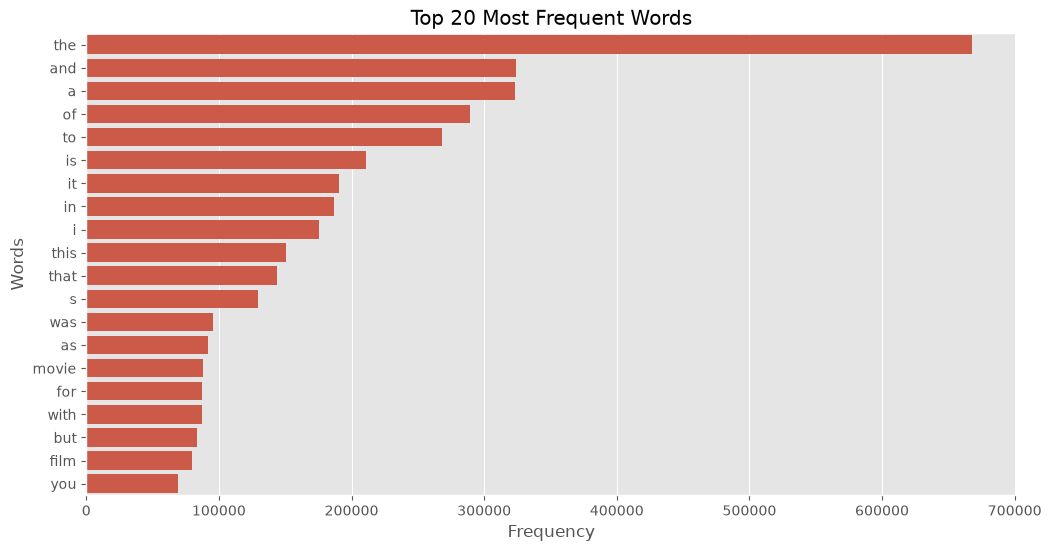

In [89]:
words = [word for word, count in top_words]

counts = [count for word, count in top_words]

plt.figure(figsize=(12,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()

### Observation

Common English words such as *the*, *and*, *movie*, and *film* dominate the frequency distribution. These words carry little sentiment information and will be removed during text preprocessing using stop-word removal.

In [90]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X = vectorizer.fit_transform(df["review"])

sum_words = X.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

words_freq = sorted(
    words_freq,
    key=lambda x: x[1],
    reverse=True
)[:20]

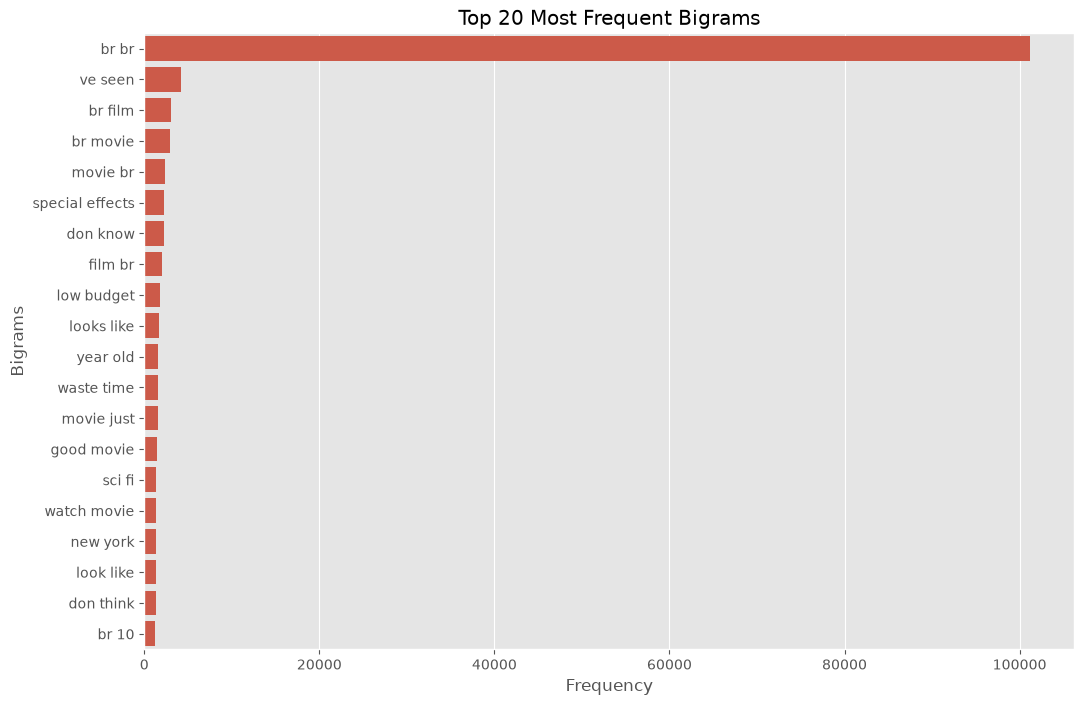

In [91]:
bigrams = [i[0] for i in words_freq]

counts = [i[1] for i in words_freq]

plt.figure(figsize=(12,8))

sns.barplot(
    x=counts,
    y=bigrams
)

plt.title("Top 20 Most Frequent Bigrams")

plt.xlabel("Frequency")

plt.ylabel("Bigrams")

plt.show()

### Observation

Frequently occurring bigrams such as *special effects*, *highly recommend*, or *waste time* provide much richer contextual information than individual words. These combinations help machine learning models understand sentiment more effectively.

# Text Preprocessing

Text preprocessing is an essential step in Natural Language Processing (NLP). Raw text often contains HTML tags, punctuation, numbers, stopwords, and inconsistent capitalization, which can negatively affect machine learning models.

In this section, a reusable preprocessing pipeline is applied to clean the movie reviews before feature extraction and model training.

## Importing the Preprocessing Module

The preprocessing functions were developed separately inside the `src/preprocessing.py` module. This allows the same cleaning pipeline to be reused during exploratory analysis, model training, prediction, and deployment.

In [92]:
import sys
import os

# Add src folder to Python path
sys.path.append(os.path.abspath("../src"))

from preprocessing import clean_text

## Testing the Preprocessing Pipeline

Before applying preprocessing to the entire dataset, a single review is cleaned to verify that each preprocessing step is working correctly.

In [93]:
sample_review = df["review"].iloc[0]

print("ORIGINAL REVIEW:\n")
print(sample_review)

print("\n" + "="*80 + "\n")

print("CLEANED REVIEW:\n")
print(clean_text(sample_review))

ORIGINAL REVIEW:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

## Applying Preprocessing to the Dataset

The `clean_text()` function is applied to every review in the dataset using the Pandas `apply()` method. A new column named `clean_review` is created to store the processed text while preserving the original reviews.

In [94]:
df["clean_review"] = df["review"].apply(clean_text)

## Comparing Original and Cleaned Reviews

The original reviews are compared with their cleaned versions to verify that HTML tags, punctuation, numbers, stopwords, and unnecessary whitespace have been removed successfully.

In [95]:
comparison = df[["review", "clean_review"]]

comparison.head(5)


,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


## Data Validation

After preprocessing, the cleaned reviews are checked for missing values and empty strings to ensure that the preprocessing pipeline has not introduced any data quality issues.

In [96]:
df["clean_review"].isnull().sum()

np.int64(0)

In [97]:
(df["clean_review"].str.strip() == "").sum()

np.int64(0)

## Word Cloud After Text Preprocessing

A new Word Cloud is generated using the cleaned reviews. Unlike the previous Word Cloud, this visualization excludes HTML tags, punctuation, numbers, and stopwords, making the most meaningful words more prominent.

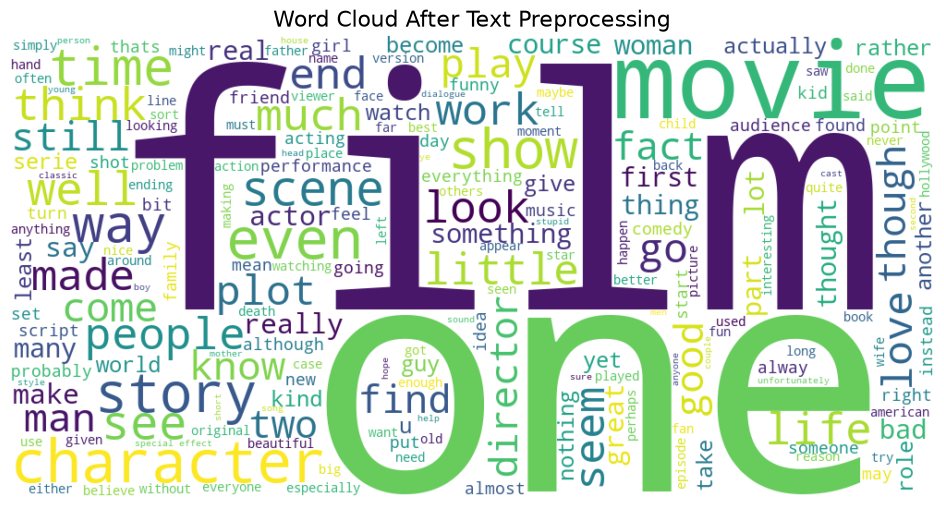

In [98]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned reviews into one string
clean_text = " ".join(df["clean_review"])

# Generate Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(clean_text)

# Plot
plt.figure(figsize=(15,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud After Text Preprocessing", fontsize=16)
plt.show()

### Observation

The cleaned Word Cloud is significantly more informative than the original one. Previously, noisy terms such as HTML tags (`br br`) appeared frequently. After preprocessing, meaningful sentiment-related words dominate the visualization, making it easier to understand the overall content of the reviews.

## Top 20 Most Frequent Words

The frequency distribution of words is analyzed after preprocessing to identify the most common terms present in the movie reviews.

In [99]:
from collections import Counter

words = clean_text.split()

word_counts = Counter(words)

top20 = word_counts.most_common(20)

top20

[('movie', 99024),
 ('film', 89807),
 ('one', 52676),
 ('like', 39789),
 ('time', 29394),
 ('good', 28615),
 ('character', 27571),
 ('get', 24434),
 ('even', 24285),
 ('story', 24229),
 ('would', 24001),
 ('make', 23564),
 ('see', 23494),
 ('really', 22900),
 ('scene', 20706),
 ('much', 18897),
 ('well', 18628),
 ('people', 17978),
 ('great', 17803),
 ('bad', 17672)]

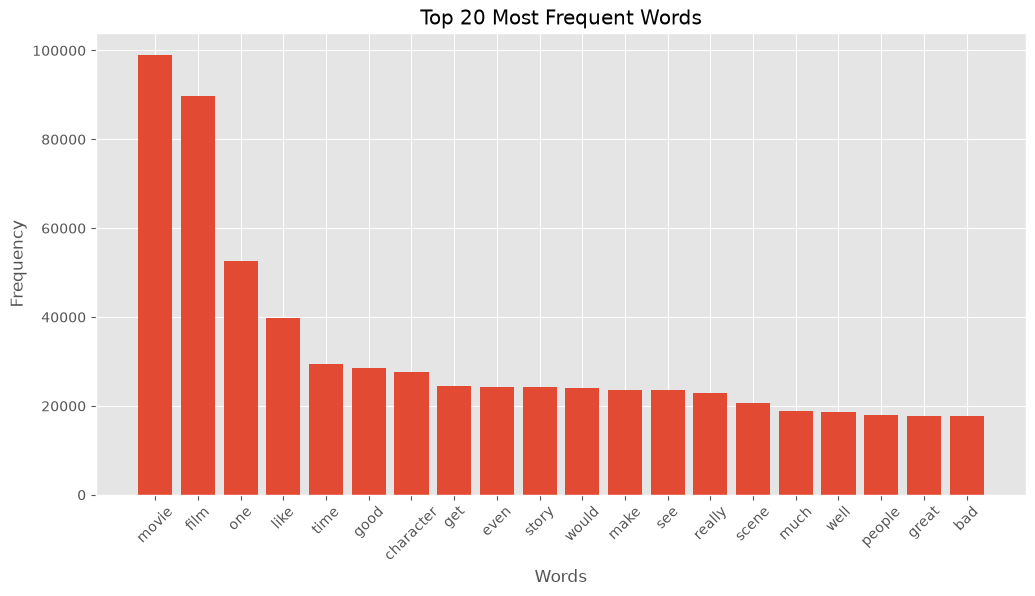

In [100]:
import pandas as pd

top_words_df = pd.DataFrame(top20, columns=["Word", "Count"])

plt.figure(figsize=(12,6))

plt.bar(top_words_df["Word"], top_words_df["Count"])

plt.xticks(rotation=45)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.title("Top 20 Most Frequent Words")

plt.show()

### Observation

After preprocessing, the most frequent words represent meaningful concepts instead of common stopwords. This confirms that the preprocessing pipeline successfully removed unnecessary words while preserving informative vocabulary.

## Top 20 Most Frequent Bigrams

A bigram is a pair of consecutive words. Analyzing bigrams helps identify common phrases that frequently appear in movie reviews.

In [101]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)

X = vectorizer.fit_transform(df["clean_review"])

sum_words = X.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

bigram_df = pd.DataFrame(words_freq, columns=["Bigram","Count"])

bigram_df

,Bigram,Count
0,look like,2880
1,ever seen,2533
2,special effect,2200
3,ive seen,2137
4,dont know,2050
5,main character,1878
6,even though,1868
7,one best,1843
8,year old,1736
9,movie like,1715


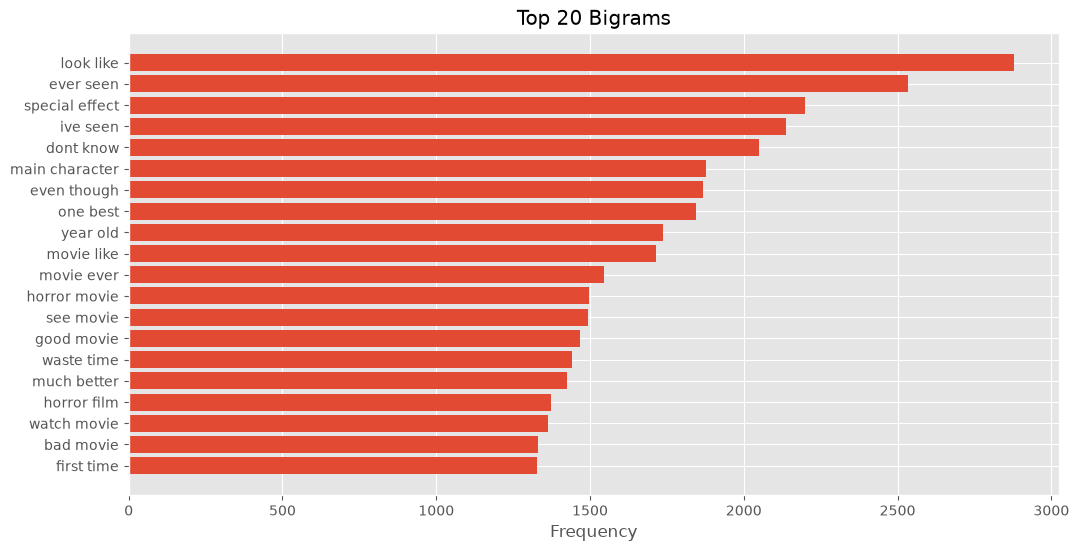

In [102]:
plt.figure(figsize=(12,6))

plt.barh(
    bigram_df["Bigram"],
    bigram_df["Count"]
)

plt.xlabel("Frequency")

plt.title("Top 20 Bigrams")

plt.gca().invert_yaxis()

plt.show()

### Observation

Unlike the raw dataset, the cleaned reviews produce meaningful word pairs instead of HTML artifacts. These bigrams provide better insight into commonly occurring phrases and improve the quality of feature extraction for machine learning.

## Saving the Clean Dataset

The cleaned dataset is saved for future stages of the project. This processed data will be used for TF-IDF feature extraction and machine learning model training.

In [103]:
df.to_csv("../data/clean_imdb_reviews.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


# Conclusion

The preprocessing stage successfully transformed raw IMDb movie reviews into clean and structured text suitable for machine learning.

The following preprocessing operations were performed:

- HTML tag removal
- URL removal
- Lowercase conversion
- Punctuation removal
- Number removal
- Stopword removal
- Lemmatization
- Extra whitespace removal

A new column named `clean_review` was created while preserving the original reviews.

The regenerated Word Cloud, frequent word analysis, and bigram analysis demonstrate that noisy terms have been removed and meaningful words now dominate the dataset.

The cleaned dataset is now ready for feature extraction using TF-IDF and machine learning model development.